In [37]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.fft import fft, fftfreq, ifft, fftshift

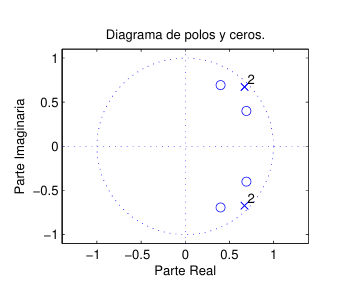

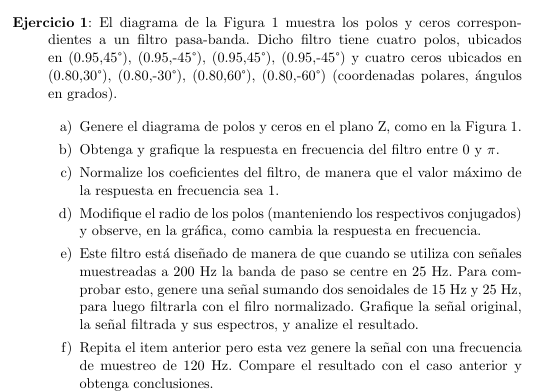

In [12]:
# Definimos Radios
r_1 = .95
r_2 = .8

#definimos Angulos
angs_1 = 45
angs_2 = 30
angs_3 = 60

# Pasamos a radianes
rads_1 = angs_1 * np.pi / 180
rads_2 = angs_2 * np.pi / 180
rads_3 = angs_3 * np.pi / 180

# Obtenemos los puntos en forma de exponencial compleja
ceros = np.array([
    r_2 * np.exp(1j * rads_2),
    r_2 * np.exp(1j * -rads_2),
    r_2 * np.exp(1j * rads_3),
    r_2 * np.exp(1j * -rads_3),
])

polos = np.array([
    r_1 * np.exp(1j * rads_1),
    r_1 * np.exp(1j * -rads_1),
    r_1 * np.exp(1j * rads_1),
    r_1 * np.exp(1j * -rads_1),
])

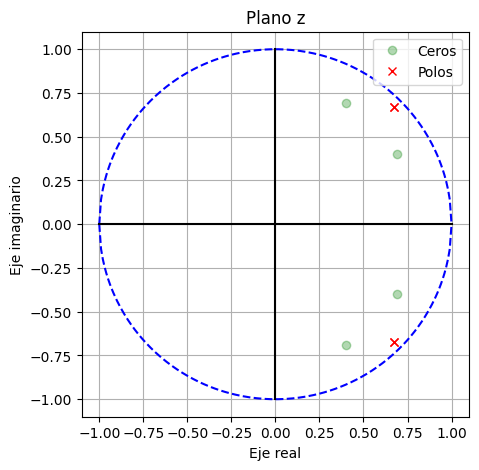

In [13]:
def graficar_plano_z(ceros, polos):
    eje_real = np.linspace(-1, 1, 200)
    eje_img = eje_real * np.tan(np.arccos(eje_real))


    plt.figure(figsize=(5,5))
    plt.title("Plano z")
    plt.plot(eje_real, eje_img, '--', c='b')
    plt.plot(eje_real, -eje_img, '--', c='b')
    plt.plot(eje_real, np.zeros_like(eje_real), c='black')
    plt.plot(np.zeros_like(eje_real), eje_real, c='black')
    plt.plot(ceros.real, ceros.imag, 'o', c='green', label='Ceros', alpha=0.3)
    plt.plot(polos.real, polos.imag, 'x', c='red', label='Polos')
    plt.xlabel("Eje real")
    plt.ylabel("Eje imaginario")
    plt.legend()
    plt.grid()
    plt.show()

graficar_plano_z(ceros, polos)

c:\Users\mateo\Desktop\facultad\IIA\4° año\PDS\Codigos\venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\mateo\Desktop\facultad\IIA\4° año\PDS\Codigos\venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


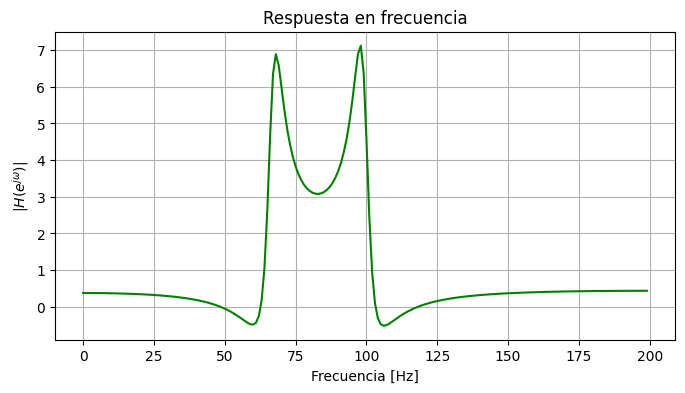

In [32]:
def obtener_H(ceros, polos, n = 200):
    numerador = np.poly(ceros)
    denominador = np.poly(polos)
    dom = np.linspace(0, np.pi, n)
    dom_cx = np.exp(1j * dom)
    H_tr = np.polyval(numerador, dom_cx) / np.polyval(denominador, dom_cx)
    angulo = np.arctan(polos[0].imag/polos[0].real)
    # Normalizar a 1
    #k = np.polyval(numerador,np.exp(1j * angulo))/np.polyval(denominador,np.exp(1j * angulo))
    
    return H_tr

H_tr = obtener_H(ceros, polos)
plt.figure(figsize=(8,4))
plt.title("Respuesta en frecuencia")
plt.plot(H_tr, c='green')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("$|H(e^{j\\omega})|$")
plt.grid()
plt.show()


In [15]:
# Probemos diferentes radios
# Definimos Radios
R = np.array([
    [0.95, 0.95], # Radios polos
    [0.55, 0.55] # Radios Ceros
])

#definimos Angulos
A = np.array([
    [60, 90], # Angulos polos
    [40, 100] # Angulos ceros
])

# Pasamos a radianes
A = A * np.pi / 180

# Obtenemos los puntos en forma de exponencial compleja
ceros = []

for i in range(len(R[1])):
    polo_i = R[1,i] * np.exp(1j * A[1,i])
    ceros.append(polo_i)
    polo_i = R[1,i] * np.exp(1j * -A[1,i])
    ceros.append(polo_i)
ceros = np.array(ceros)

polos = []
for i in range(len(R[0])):
    polo_i = R[0,i] * np.exp(1j * A[0,i])
    polos.append(polo_i)
    polo_i = R[0,i] * np.exp(1j * -A[0,i])
    polos.append(polo_i)
polos = np.array(polos)

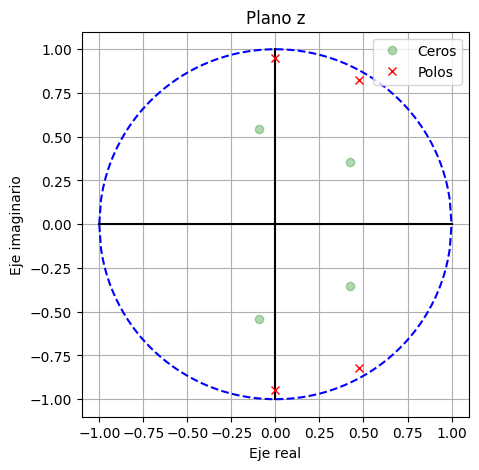

In [16]:
graficar_plano_z(ceros, polos)

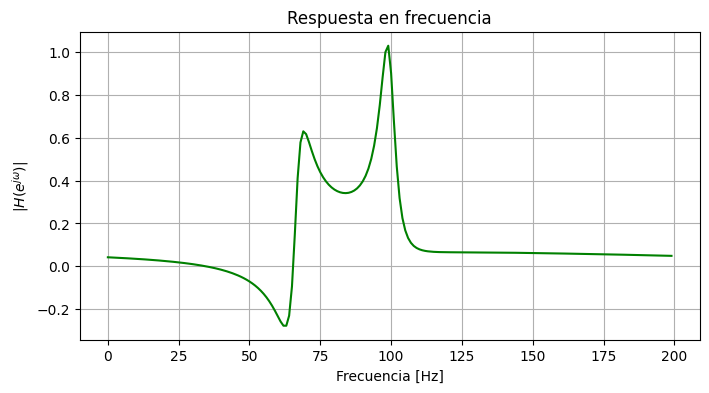

In [17]:
H_tr = obtener_H(ceros, polos)
H_tr = H_tr/np.max(H_tr)
plt.figure(figsize=(8,4))
plt.title("Respuesta en frecuencia")
plt.plot(H_tr, c='green')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("$|H(e^{j\\omega})|$")
plt.grid()
plt.show()


In [18]:
def senoidal(N, frecs, frecM):
    dom = np.arange(0, N, 1/frecM)

    senoidal_final = np.zeros_like(dom)
    for f in range(len(frecs)):
        senoidal = np.sin(dom * 2 * np.pi * frecs[f])
        senoidal_final += senoidal
    
    return senoidal_final

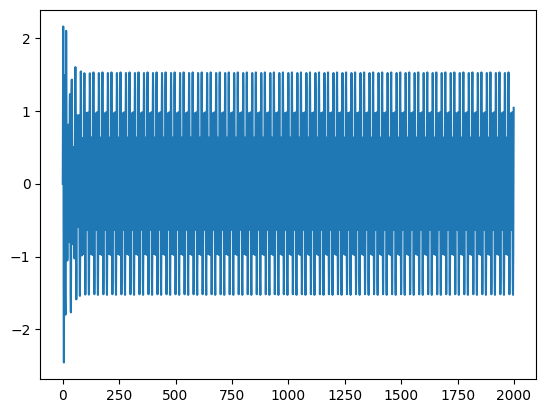

c:\Users\mateo\Desktop\facultad\IIA\4° año\PDS\Codigos\venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\mateo\Desktop\facultad\IIA\4° año\PDS\Codigos\venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


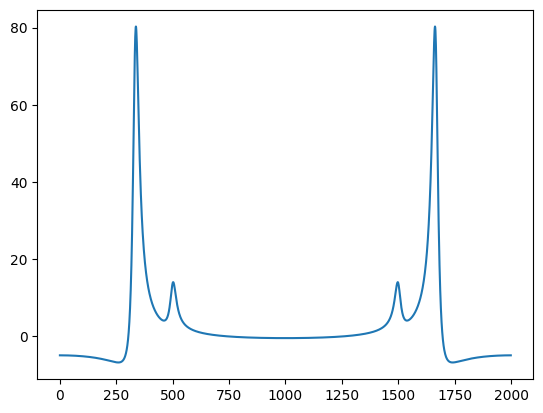

In [40]:
n = 10
frec_senoidales = [15,25]
frec_muestreo = 200
puntos = n * frec_muestreo
senial = senoidal(n,frec_senoidales,frec_muestreo)


sos = signal.zpk2sos(ceros, polos, 1)

# 2. Aplicar el filtro directamente a la señal en el tiempo
senial_filtrada = signal.sosfilt(sos, senial)

# 3. Si quieres evitar el desfase (filtrado hacia adelante y atrás)
senial_filtrada_zero_phase = signal.sosfiltfilt(sos, senial)
s_filter_frec = fft(senial_filtrada_zero_phase,puntos)

plt.plot(senial_filtrada)
plt.show()
plt.plot(s_filter_frec)